In [8]:
import numpy as np
from astropy.wcs import WCS
from astropy.io import fits
import astropy.units as u
import matplotlib.pyplot as plt
import astropy.convolution as conv
from astropy.coordinates import SkyCoord, AltAz, EarthLocation, Angle
from astropy.time import Time
import src.beam as bm
from scipy.ndimage import shift
from IPython import embed
from astropy.table import Table
from astropy.visualization import ZScaleInterval
zscale = ZScaleInterval()
from mpl_toolkits.axes_grid1 import make_axes_locatable
import src.pointing as pt
import pickle
import warnings
import pandas as pd
import scipy.constants as cst
from astropy.stats import gaussian_fwhm_to_sigma
from specutils import Spectrum1D
from specutils.manipulation import FluxConservingResampler

noise_model_HF = pd.read_csv('/home/mvancuyck/Desktop/gmca/src/TIM_SW_loading.tsv', sep='\t')
#The Low Freauency (LF) arrays will measure the lower frequencies
noise_model_LF = pd.read_csv('/home/mvancuyck/Desktop/gmca/src/TIM_LW_loading.tsv', sep='\t')

In [10]:
#TIM parameters. 
#------------------------------------------------------------
lambda_HF = noise_model_HF["# Wavelength[um]"]*1e3 #nm
nu_HF = cst.c/(lambda_HF*1e-9)/1e9 #GHz
nHF = noise_model_HF["NEI[Jy/sr s^1/2]"]
#------------------------------------------------------------
lambda_LF = noise_model_LF["# Wavelength[um]"]*1e3 #nm
nu_LF = cst.c/(lambda_LF*1e-9)/1e9 #GHz
nLF = noise_model_LF["NEI[Jy/sr s^1/2]"]
#------------------------------------------------
from specutils import Spectrum1D
from specutils.manipulation import FluxConservingResampler

#------------------------------------------------------------
#Combine the LF and HF arrays into 1 array. 
freqs = np.concatenate((nu_LF[::-1], nu_HF[::-1]))
noise = (np.concatenate((nLF[::-1], nHF[::-1]))*u.Jy/u.sr)
lambdaw = np.concatenate((lambda_HF, lambda_LF)) /1e3 #um
noisew = (np.concatenate((nHF, nLF))*u.Jy/u.sr)
#------------------------------------------------------------
telescope_diameter = 2 #m
fwhm =  1.22  * cst.c / (freqs * 1e9 * telescope_diameter) * u.rad
fwhmw = 1.22 * lambdaw * 1e-6 / telescope_diameter * u.rad
#The beam solid angle in steradiant for a Gaussian is: 
Omega_beam  = (2*np.pi*(fwhm * gaussian_fwhm_to_sigma)**2).to(u.sr)
Omega_beamw = (2*np.pi*(fwhmw* gaussian_fwhm_to_sigma)**2).to(u.sr)
#---------------------------
NEFDw = noisew * Omega_beamw
NEFD = noise   * Omega_beam
#So NEFDw is the noise per beam (per √s), i.e. how noisy a single observation of a beam-sized patch is.

median NEFD= 3.660428697159366 Jy
median NEI= 82.59366765042816 Jy / sr MJy/sr


/tmp/ipykernel_9258/886404011.py:23: RuntimeWarning: divide by zero encountered in divide
  def w_to_f(x): return cst.c/(x*1e-6)/1e9


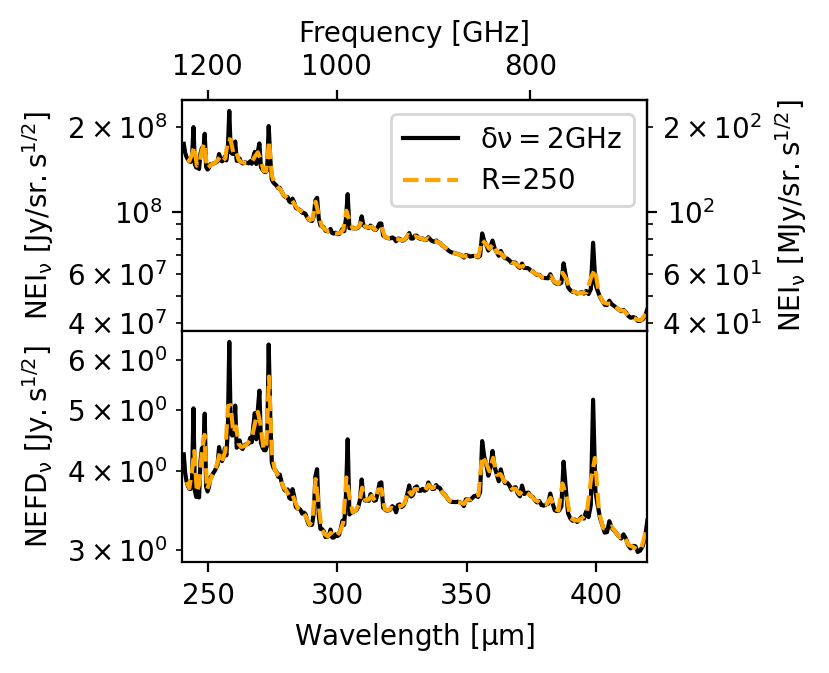

In [25]:
R = 250
dlognu = np.log(1 + 1/R)
nu_min = 715
nu_max = 1250
N = int(np.floor((np.log(nu_max) - np.log(nu_min)) / dlognu)) + 1
resampled_freqs = nu_min * (1 + 1/R) ** np.arange(N)
resampled_lw = cst.c / (resampled_freqs*1e9) / 1e-6
fwhm = 1.22  * cst.c / (resampled_freqs * 1e9 * telescope_diameter) * u.rad
Omega_beam_resampled  = (2*np.pi*(fwhm * gaussian_fwhm_to_sigma)**2).to(u.sr)
dnu = resampled_freqs*dlognu

fig, (ax, ax2) = plt.subplots(2,figsize=(3,3), dpi=200, sharex=True )  
ax.loglog(lambdaw, noisew,  c='k', label = '$\\rm \\delta \\nu = 2GHz$' )

ax2.loglog(lambdaw, NEFDw,  c='k' )
print('median NEFD=', np.median(NEFDw) )
ax2.set_xlabel("Wavelength [$\\rm \\mu$m]")
ax.set_ylabel("NEI$\\rm _{\\nu}$ $\\rm [Jy/sr.s^{1/2}]$")
ax2.set_ylabel("NEFD$\\rm _{\\nu}$ [$\\rm Jy.s^{1/2}$]")

ax.set_xscale("linear")
ax.set_xlim(240,420)
def w_to_f(x): return cst.c/(x*1e-6)/1e9
secax = ax.secondary_xaxis("top", functions=(w_to_f,w_to_f))
secax.set_xlabel('Frequency [GHz]')

def jy_to_njy(x): return x/1e6
secax = ax.secondary_yaxis("right", functions=(jy_to_njy,jy_to_njy))
secax.set_ylabel("NEI$\\rm _{\\nu}$ $\\rm [MJy/sr.s^{1/2}]$")
fig.subplots_adjust(wspace=0, hspace=0)

spec = Spectrum1D(spectral_axis=freqs*u.GHz, flux=NEFD)
fluxc_resample = FluxConservingResampler()
sed_in_tim = fluxc_resample(spec, resampled_freqs*u.GHz) 
nefd_resampled = sed_in_tim.flux
ax2.plot( cst.c / (resampled_freqs*1e9) / 1e-6, nefd_resampled, ls = '--', c='orange', )
ax.plot( cst.c / (resampled_freqs*1e9) / 1e-6,  nefd_resampled/Omega_beam_resampled, ls = '--', c='orange', label = 'R=250')
ax.legend()
model = nefd_resampled/Omega_beam_resampled
print('median NEI=', np.nanmedian(model) / 1e6, 'MJy/sr' )

In [12]:
results_relatdiff = pickle.load(open('results_relatdiff.p', 'rb'))
results = results_relatdiff['results']
SNR_list = np.abs(np.asarray(results_relatdiff['SNR_list']))
backgrounbd_list = results_relatdiff['backgrounbd_list']
realizations = results_relatdiff['realizations']
#res_list = results_relatdiff['res_list']
res_list = (5,10,15,20)

/tmp/ipykernel_9258/1132698642.py:4: RuntimeWarning: All-NaN slice encountered
  results_avg = np.nanmedian(results[:,ires,:,:], axis=0)
/home/mvancuyck/anaconda3/envs/myenv/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


<Figure size 640x480 with 0 Axes>

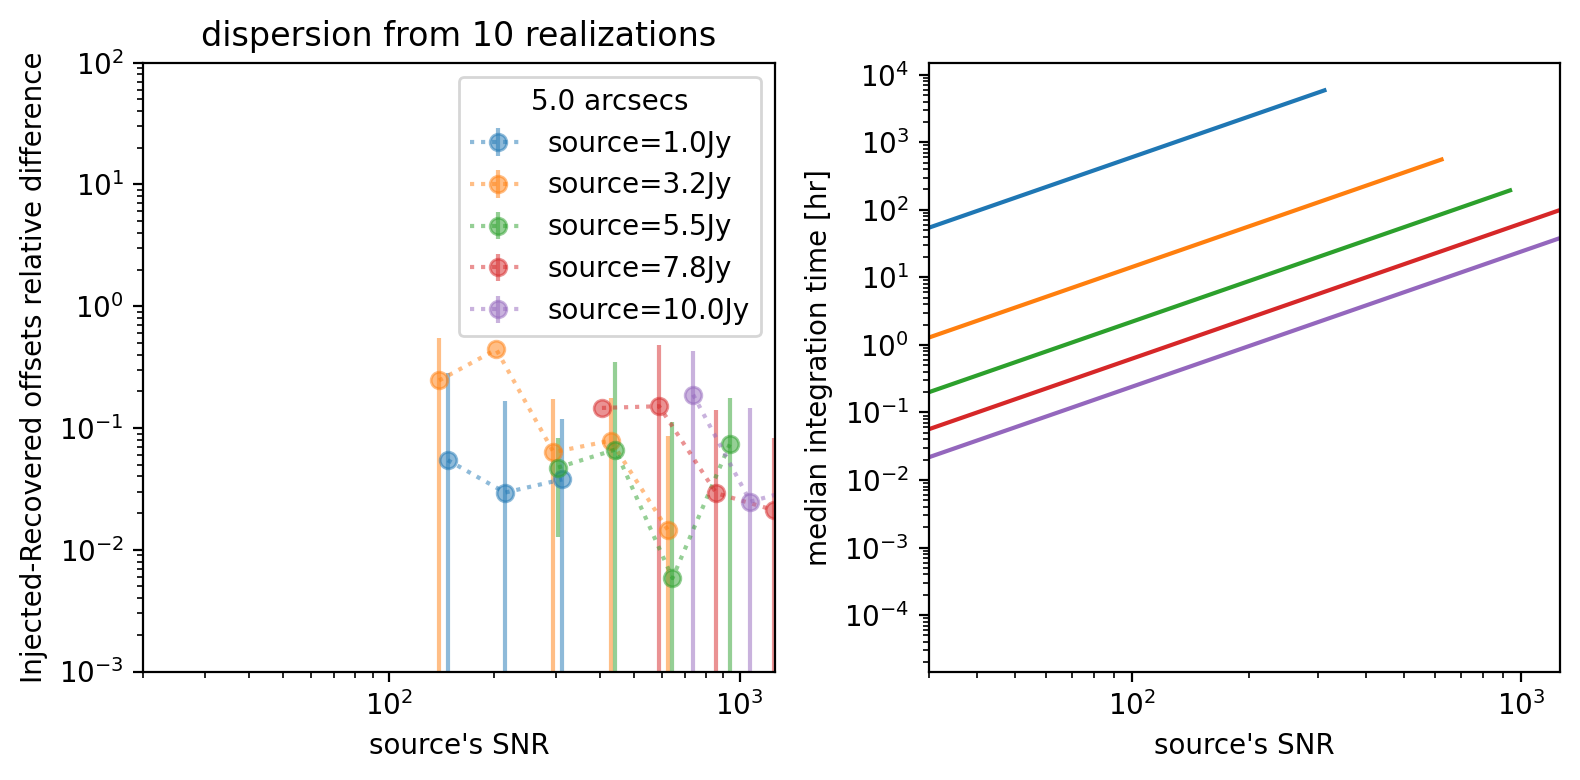

<Figure size 640x480 with 0 Axes>

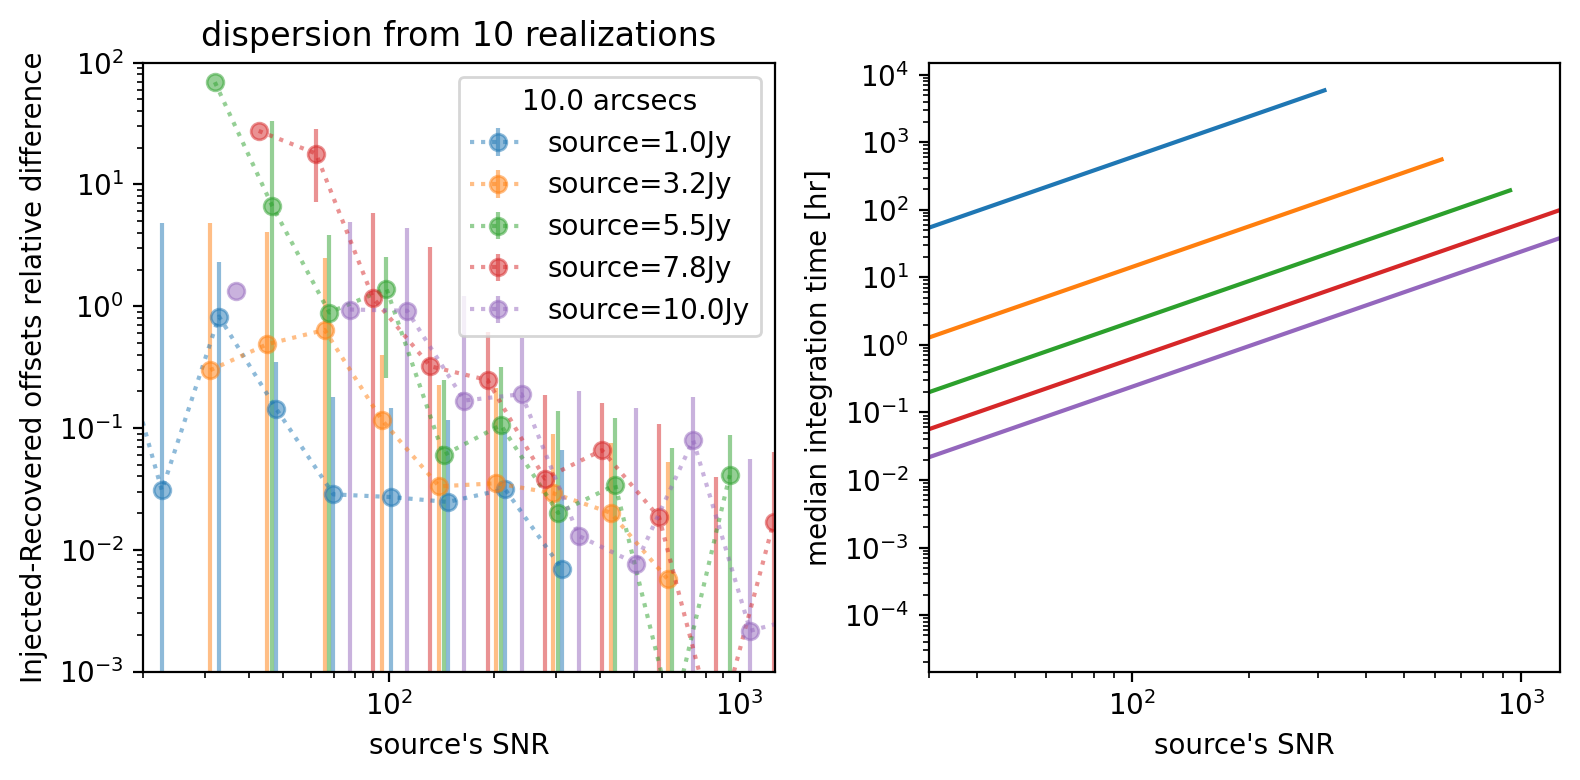

<Figure size 640x480 with 0 Axes>

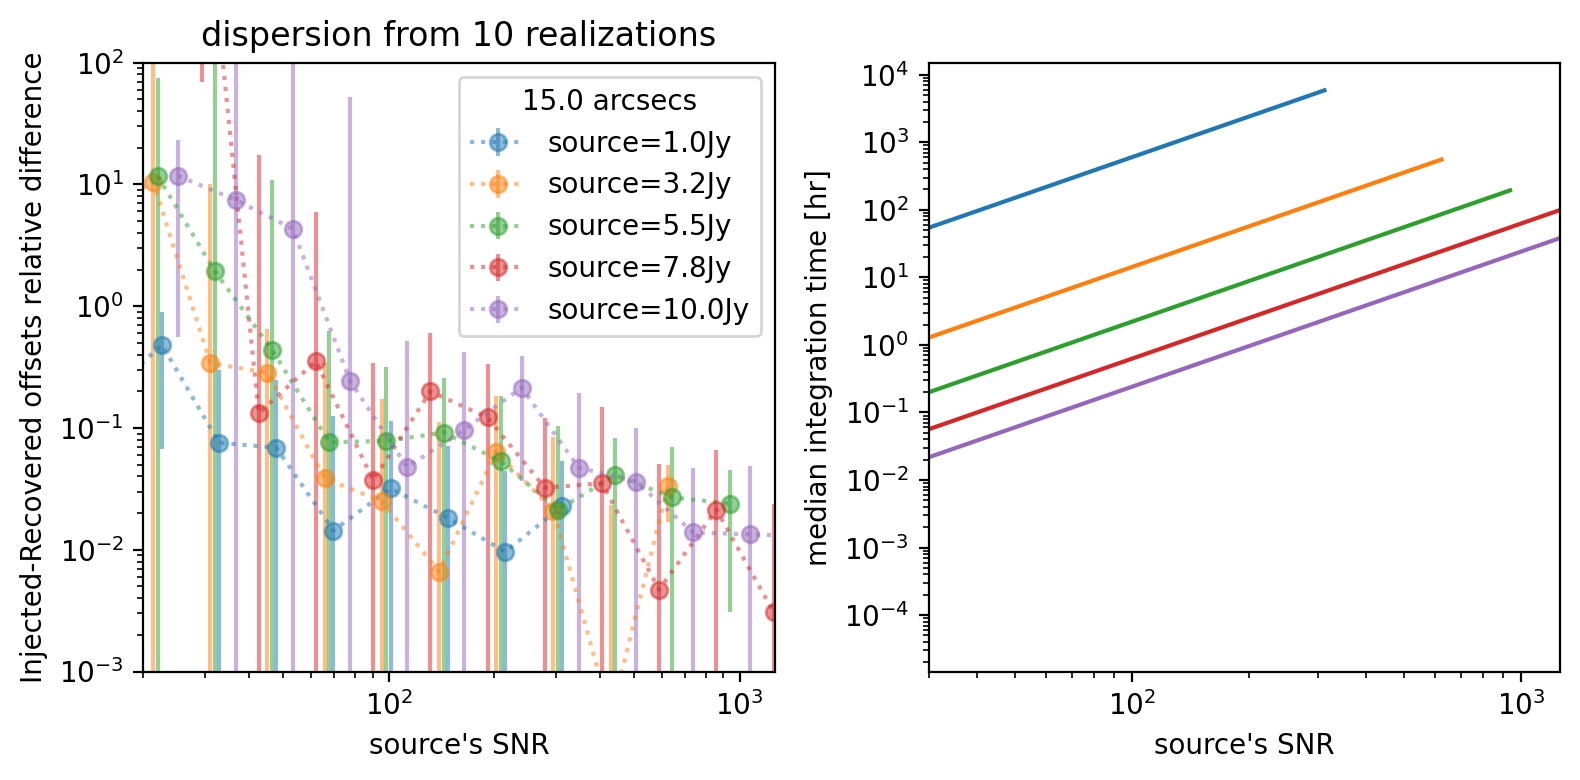

<Figure size 640x480 with 0 Axes>

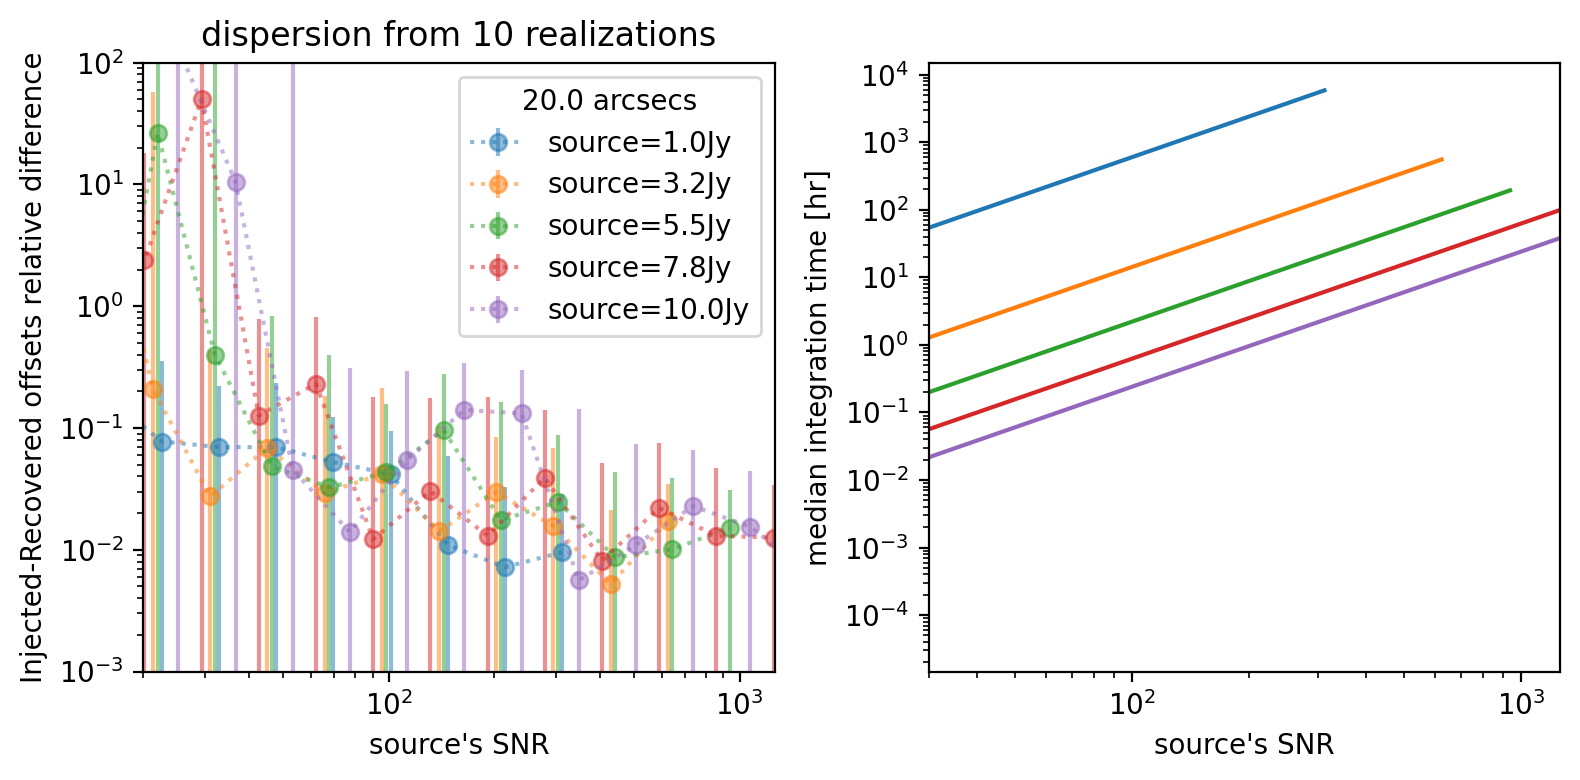

In [31]:
for ires, res in enumerate(res_list):
    plt.figure()
    fig, ax = plt.subplots(1,2, figsize=(8,4),dpi=200)
    results_avg = np.nanmedian(results[:,ires,:,:], axis=0)
    results_std = np.nanstd(results[:,ires,:,:], axis=0)
    for ib, b in enumerate(backgrounbd_list):
            x_offset =  (1 + 1 * ((ib+2.5) - len(backgrounbd_list)/2))/4
            ax[0].errorbar(SNR_list *x_offset, np.abs(results_avg[ib,:]),yerr=results_std[ib,:],alpha=0.5, label =f'source={b:.1f}Jy', ls = ':', fmt='o')  

            t =np.nanmedian( (SNR_list[:,None]*nefd_resampled[None,:]/b)**2, axis=1)
            ax[1].loglog(SNR_list*x_offset, t/3600)
            
    ax[1].set_xlim(3e1, SNR_list.max()+10)
    ax[1].set_ylabel('median integration time [hr]')
    ax[0].set_xlim(2e1, SNR_list.max()+10)
    ax[0].set_ylim(1e-3,1e2)
    ax[0].set_yscale('log')
    ax[0].set_xscale('log')
    ax[0].legend(title=f'{res:.1f} arcsecs')
    ax[0].set_title(f'dispersion from {realizations} realizations')
    ax[0].set_ylabel('Injected-Recovered offsets relative difference')
    ax[0].set_xlabel("source's SNR");ax[1].set_xlabel("source's SNR")
    fig.tight_layout()

/tmp/ipykernel_9258/915669953.py:3: RuntimeWarning: All-NaN slice encountered
  results_avg = np.nanmedian(results[:,:,ib,:], axis=0)


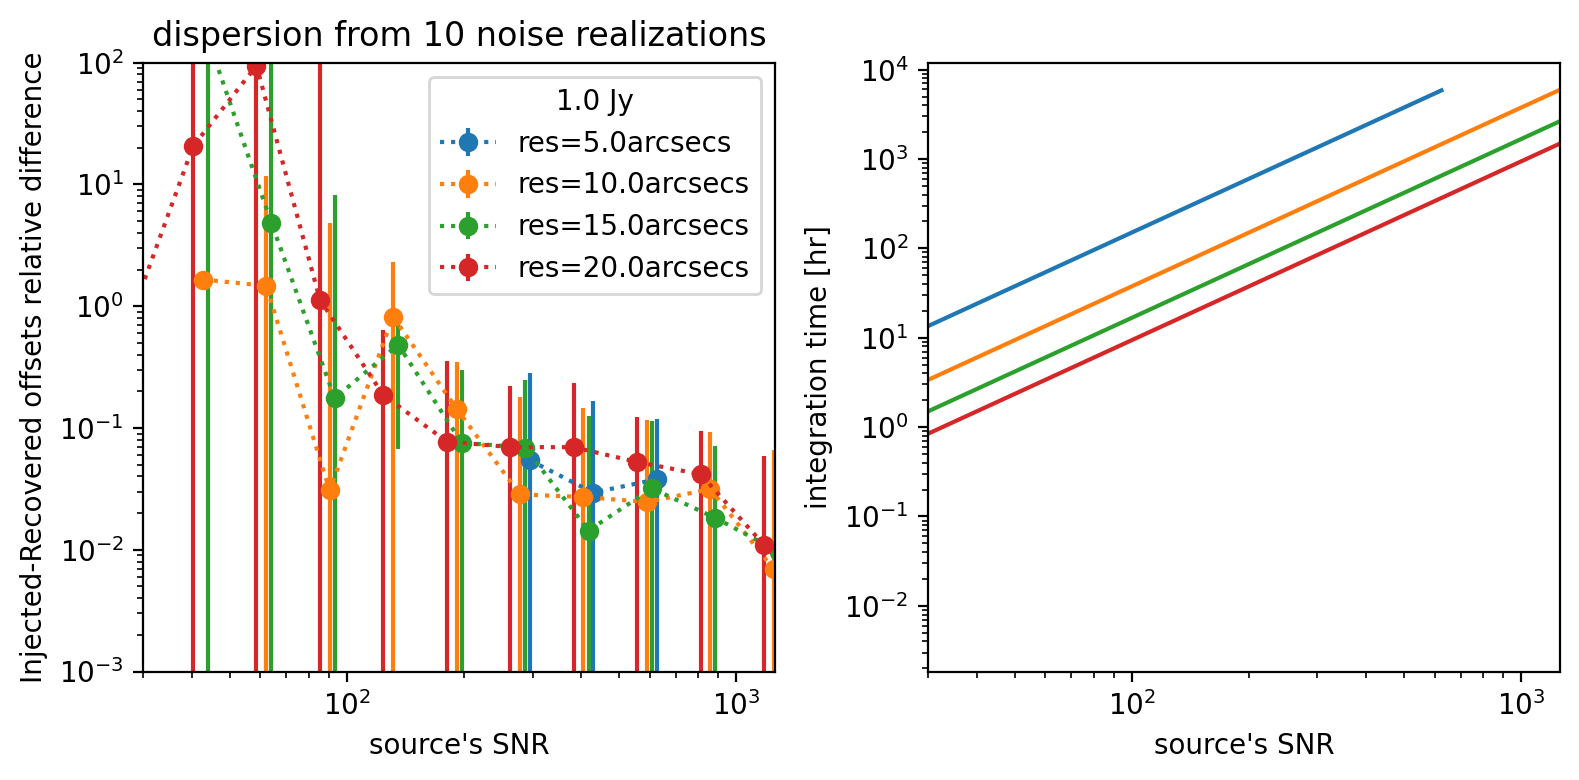

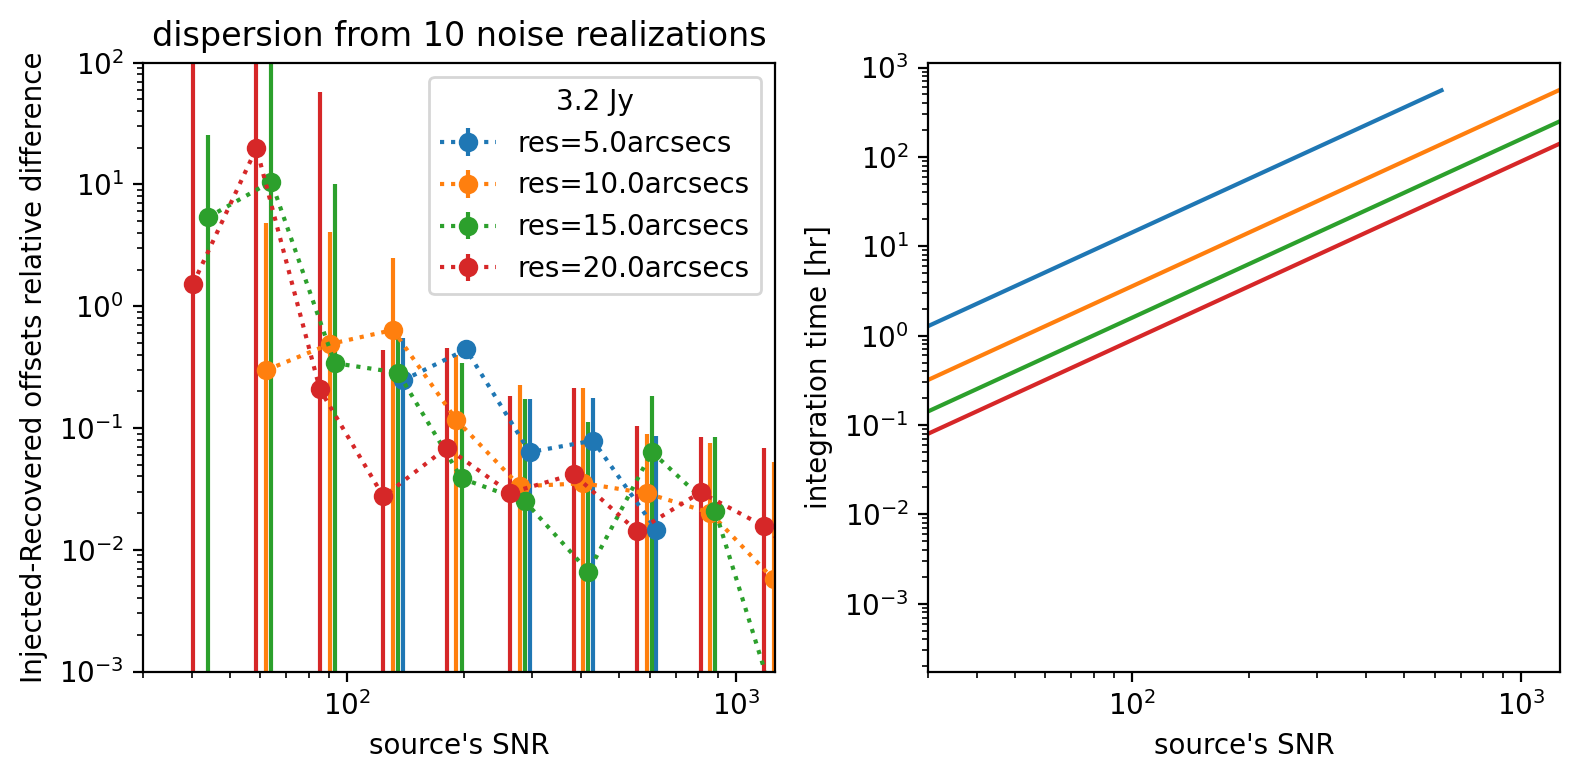

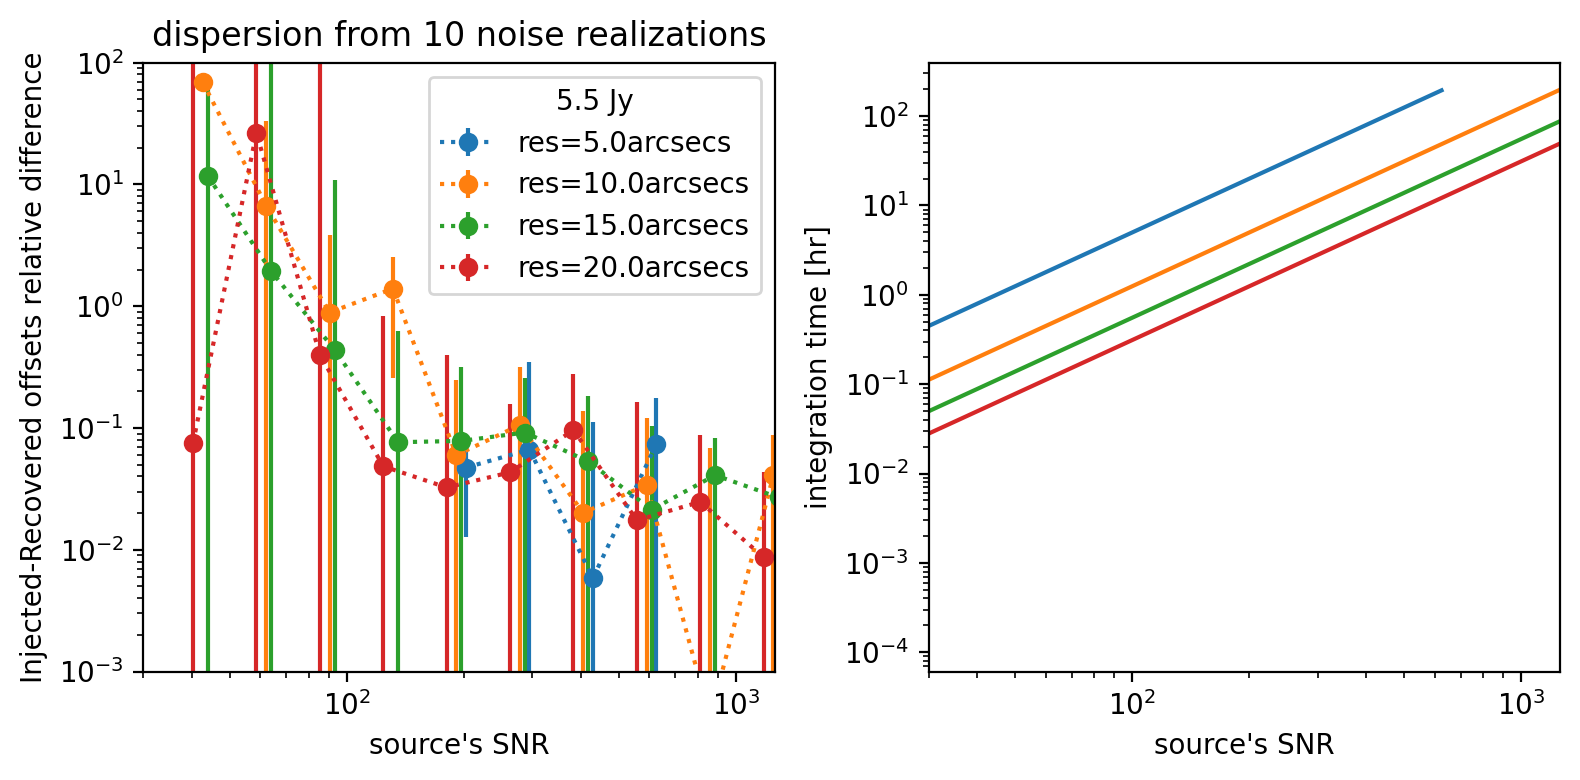

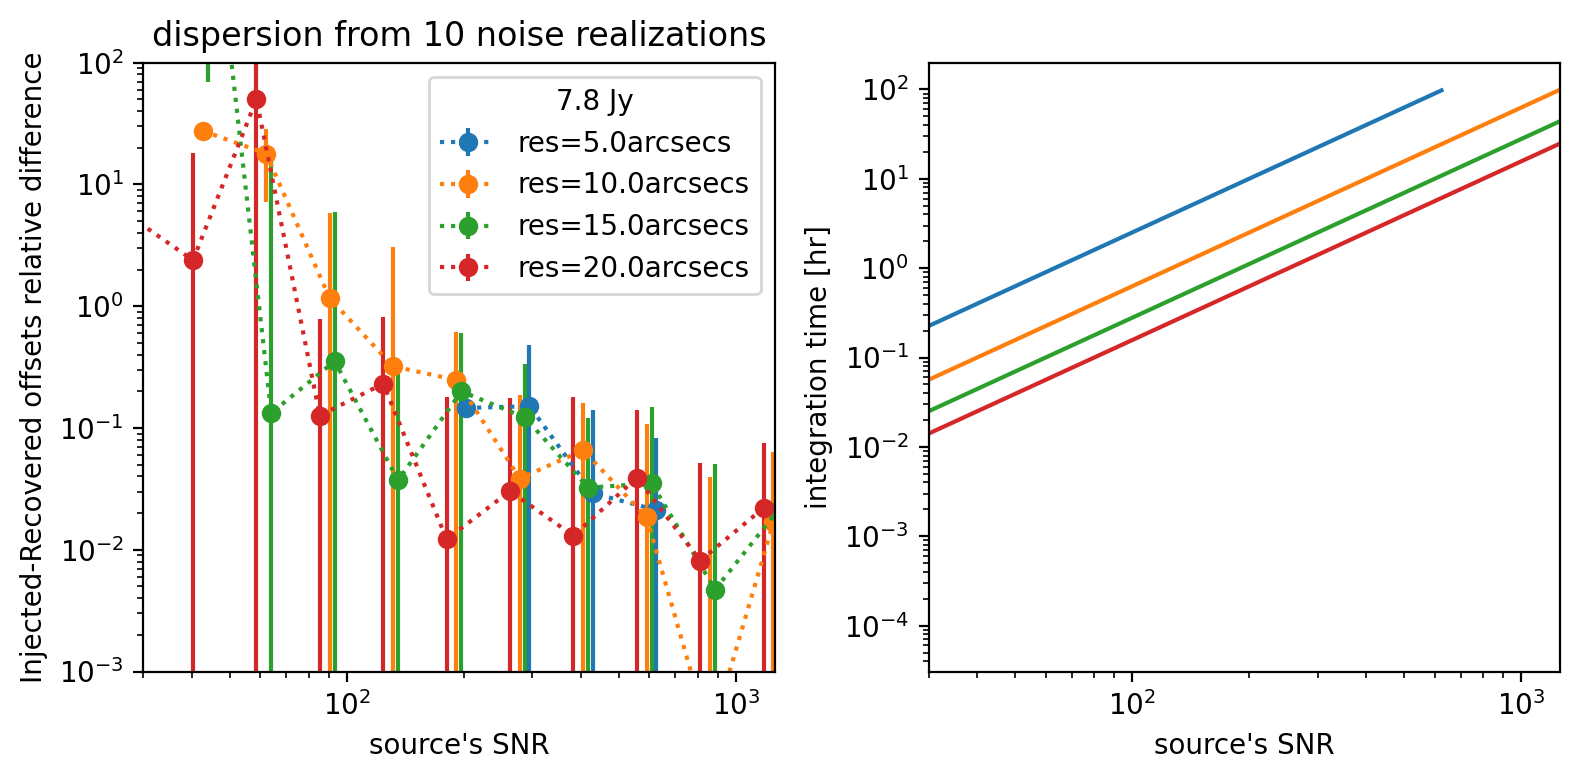

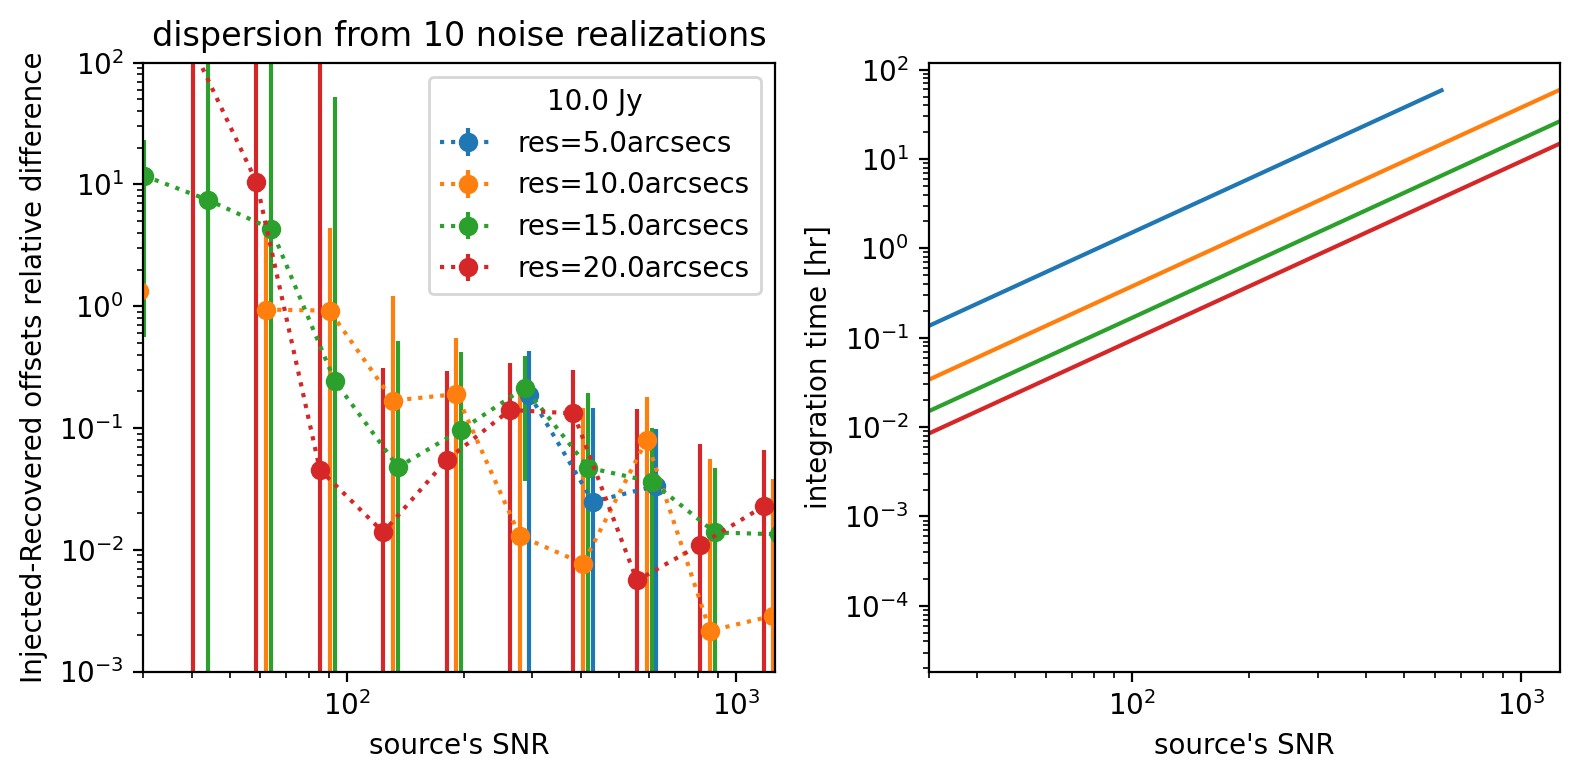

In [33]:
for ib, flux in enumerate(backgrounbd_list):
        fig, ax = plt.subplots(1,2, figsize=(8,4),dpi=200)
        results_avg = np.nanmedian(results[:,:,ib,:], axis=0)
        results_std = np.nanstd(results[:,:,ib,:], axis=0)
        for ires, res in enumerate(res_list):
                x_offset =  (1 + 1 * ((ires+2.5) - len(backgrounbd_list)/2))/2
                ax[0].errorbar(SNR_list*x_offset, 
                             np.abs(results_avg[ires,:]),
                             yerr=results_std[ires,:],
                             label =f'res={res:.1f}arcsecs', ls = ':', fmt='o')
                t =np.nanmedian( (SNR_list[:,None]*nefd_resampled[None,:]/flux)**2, axis=1)
                ax[1].loglog(SNR_list*x_offset, t/3600)

        ax[0].set_xlim(3e1, SNR_list.max()+10); ax[1].set_xlim(3e1, SNR_list.max()+10)
        ax[0].set_ylim(1e-3,1e2); 
        ax[0].set_yscale('log'); ax[0].set_xscale('log')
        ax[0].legend(title=f'{flux:.1f} Jy')

        ax[0].set_title(f'dispersion from {realizations} noise realizations')
        ax[0].set_ylabel('Injected-Recovered offsets relative difference')
        ax[1].set_ylabel('integration time [hr]')
        ax[0].set_xlabel("source's SNR");ax[1].set_xlabel("source's SNR")
        fig.tight_layout()

        